## ML Classical Baselines

In [7]:
import pandas as pd
from IPython.display import display

from utils.config import (
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
)
from utils.ML.ml_pipeline import (
    best_confusion_predictions,
    get_cache_path,
    get_results_path,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_or_build_none_reference_features,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    print_normalization_discriminability,
    process_magnitude_data,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_block_vs_lovo_position_accuracy,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_lovo_fold_spread,
    plot_magnitude_analysis_interactive,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [8]:
CALIBRATION_MODE = "none"   # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"  # per_session | per_user | global (empty_baseline only)
SHOW_MAGNITUDE_PLOT = False   # True -> interactively plot raw vs normalized CSI

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

# MODELS_TO_RUN = ("RF", "KNN", "SVM")
MODELS_TO_RUN = ("RF", )
SPLIT_MODES = ("random",)  # cross_session, lovo, random, block
RUN_GRID_SEARCH = False
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
SVM_KERNEL = "rbf"            # "rbf" | "linear"
N_JOBS = -1

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
if preproc_opts.get("normalization") == "empty_baseline":
    preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
tables_dir = results_dir / "tables"
tuning_dir = results_dir / "tuning"
plots_dir = results_dir / "plots"
for directory in (tables_dir, tuning_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results


## Raw Data

In [9]:
magnitude_data, csv_diagnostics = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
)

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19


In [24]:
rows = []
for _, locations in magnitude_data.items():
    for location, users in locations.items():
        for user, esps in users.items():
            for esp, trials in esps.items():
                for magnitude in trials.values():
                    if magnitude is not None:
                        rows.append(
                            (
                                user.removeprefix("user_"),
                                location.removeprefix("location_"),
                                esp.removeprefix("esp_"),
                                int(magnitude.shape[0]),
                            )
                        )

packet_counts = pd.DataFrame(
    rows,
    columns=["user", "position", "esp", "n_packets"],
).sort_values(["user", "position", "esp"])
display(
    packet_counts.groupby(["user", "position"], sort=True).agg(
        esp=("esp", list),
        n_packets=("n_packets", list),
        min_n_packets=("n_packets", "min"),
        max_n_packets=("n_packets", "max"),
    )
)

# after inspecting which ones they are
threshold = 1500  # adjust once you've looked at the distribution
bad = packet_counts[packet_counts["n_packets"] < threshold]
display(bad)  # confirm these are the ones to exclude, and why

packet_counts[packet_counts["esp"] == "09"]["n_packets"].describe()

esp  \
user position                                                      
01   A-1       [01, 01, 02, 02, 03, 03, 04, 04, 05, 05, 07, 0...   
     A-13      [01, 01, 02, 02, 03, 03, 04, 04, 05, 05, 07, 0...   
     A-14      [01, 01, 02, 02, 03, 03, 04, 04, 05, 05, 07, 0...   
     A-2       [01, 01, 02, 02, 03, 03, 04, 04, 05, 05, 07, 0...   
     A-5       [01, 01, 02, 02, 03, 03, 04, 04, 05, 05, 07, 0...   
...                                                          ...   
06   F-12      [01, 02, 03, 04, 05, 07, 08, 09, 10, 11, 12, 1...   
     F-13      [01, 02, 03, 04, 05, 07, 08, 09, 10, 11, 12, 1...   
     F-5       [01, 02, 03, 04, 05, 07, 08, 09, 10, 11, 12, 1...   
     F-8       [01, 02, 03, 04, 05, 07, 08, 09, 10, 11, 12, 1...   
     Z-0       [01, 02, 03, 04, 05, 07, 08, 09, 10, 11, 12, 1...   

                                                       n_packets  \
user position                                                      
01   A-1       [1842, 1958, 1838, 1995, 1866, 1890, 1963, 183...   
     A-13      [2092, 1855, 2148, 1841, 1922, 1856, 1851, 204...   
     A-14      [2013, 1833, 2015, 1819, 1874, 1853, 1825, 193...   
     A-2       [1828, 1960, 1832, 1971, 1906, 1840, 1973, 183...   
     A-5       [1928, 1862, 1958, 1846, 1853, 1853, 1884, 184...   
...                                                          ...   
06   F-12      [1936, 1834, 1730, 1694, 1821, 1735, 1948, 144...   
     F-13      [1952, 1883, 1786, 1705, 1869, 1745, 1882, 146...   
     F-5       [1871, 1877, 1810, 1723, 1853, 1862, 1951, 161...   
     F-8       [1976, 1971, 1883, 1837, 1946, 1863, 1894, 162...   
     Z-0       [2198, 2185, 2121, 2065, 2236, 2094, 1916, 173...   

               min_n_packets  max_n_packets  
user position                                
01   A-1                1790           2173  
     A-13               1835           2148  
     A-14               1818           2067  
     A-2                1824           2207  
     A-5                1718           2255  
...                      ...            ...  
06   F-12               1440           2043  
     F-13               1462           2044  
     F-5                1610           2225  
     F-8                1620           2155  
     Z-0                1736           2236  

[317 rows x 4 columns]

,user,position,esp,n_packets
3915,02,C-6,01,1444
3923,02,C-6,02,1443
3927,02,C-6,03,1322
3918,02,C-6,04,1313
3917,02,C-6,05,1439
...,...,...,...,...
5589,06,E-13,09,1431
7283,06,E-6,09,1453
8489,06,F-11,09,1433
2934,06,F-12,09,1440


count     476.000000
mean     1807.397059
std       161.287099
min       939.000000
25%      1759.750000
50%      1860.000000
75%      1902.000000
max      2150.000000
Name: n_packets, dtype: float64

In [23]:
packet_counts["n_packets"].describe()

count    9044.000000
mean     1940.999115
std       126.379737
min       939.000000
25%      1881.000000
50%      1926.000000
75%      1990.000000
max      2617.000000
Name: n_packets, dtype: float64

In [4]:
if SHOW_MAGNITUDE_PLOT:
    processed_magnitude_data, _ = process_magnitude_data(magnitude_data, **preproc_opts)
    print("=== RAW magnitudes (before normalization) ===")
    plot_magnitude_analysis_interactive(magnitude_data)
    print(
        "=== NORMALIZED magnitudes (after normalization: "
        f"{preproc_opts.get('normalization', 'none')}) ==="
    )
    plot_magnitude_analysis_interactive(processed_magnitude_data)
    del processed_magnitude_data

#### Feature Dataframes

In [25]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)

none_reference_dataframes = (
    feature_dataframes
    if preproc_opts.get("normalization") == "none"
    else load_or_build_none_reference_features(
        magnitude_data,
        active_preproc_opts=preproc_opts,
        feat_opts=feat_opts,
    )
)
fisher_diagnostics = print_normalization_discriminability(
    feature_dataframes,
    normalization=preproc_opts.get("normalization", "none"),
    reference_feature_dataframes=none_reference_dataframes,
    bands_to_run=BANDS_TO_RUN,
)
display(fisher_diagnostics)
del magnitude_data


[features] resolved cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/2_4ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/5ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/fusion.parquet
2.4 GHz: 13588 windows, 2708 columns
5 GHz: 14478 windows, 3368 columns
Fusion: 13568 windows, 6068 columns
[normalization diagnostic] none reference cache: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-none/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc

,dataset,normalization,median_fisher_ratio,none_median_fisher_ratio
0,2.4 GHz,empty_baseline,0.035751,0.028427
1,5 GHz,empty_baseline,0.070829,0.030535
2,Fusion,empty_baseline,0.050150,0.029641


In [31]:
feature_dataframes["2.4 GHz"]

,frequency_scenario,scenario,location,user,trial,group_id,window_idx,label,esp_01_mean_sc_00,esp_01_mean_sc_01,...,esp_10_energy_sc_40,esp_10_energy_sc_41,esp_10_energy_sc_42,esp_10_energy_sc_43,esp_10_energy_sc_44,esp_10_energy_sc_45,esp_10_energy_sc_46,esp_10_energy_sc_47,esp_10_energy_sc_48,esp_10_energy_sc_49
0,2.4 GHz,1,C-1,06,01,scenario_1_location_C-1_user_06_trial_01,0,1,-0.143600,-0.126188,...,0.652520,0.742348,0.740510,0.605407,0.453647,0.624252,0.806132,0.881275,0.883309,0.948152
1,2.4 GHz,1,C-1,06,01,scenario_1_location_C-1_user_06_trial_01,1,1,-0.151065,-0.136440,...,0.636206,0.660530,0.573047,0.433481,0.293555,0.460776,0.637013,0.748106,0.728536,0.779052
2,2.4 GHz,1,C-1,06,01,scenario_1_location_C-1_user_06_trial_01,2,1,-0.155256,-0.143489,...,0.851987,1.384502,1.449677,1.017997,0.494631,0.313540,0.335948,0.536700,0.779625,0.937027
3,2.4 GHz,1,C-1,06,01,scenario_1_location_C-1_user_06_trial_01,3,1,-0.139401,-0.131681,...,1.021276,1.627249,1.688684,1.126296,0.475474,0.228045,0.271541,0.526211,0.748349,0.908278
4,2.4 GHz,1,C-1,06,01,scenario_1_location_C-1_user_06_trial_01,4,1,-0.149935,-0.145400,...,0.384069,0.304154,0.268994,0.226671,0.271015,0.484141,0.734558,0.906226,0.902365,0.811093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13583,2.4 GHz,1,C-4,02,01,scenario_1_location_C-4_user_02_trial_01,24,1,0.034243,0.033979,...,3.702713,2.325990,1.554480,0.776574,0.296778,0.578838,1.309653,2.326932,3.019722,2.520702
13584,2.4 GHz,1,C-4,02,01,scenario_1_location_C-4_user_02_trial_01,25,1,0.102039,0.071389,...,4.170402,2.566762,1.669464,0.751631,0.285474,0.629702,1.434962,2.591960,3.497643,2.845963
13585,2.4 GHz,1,C-4,02,01,scenario_1_location_C-4_user_02_trial_01,26,1,0.093724,0.067386,...,3.794082,2.387062,1.557159,0.746307,0.286201,0.666710,1.581614,2.686604,3.590096,2.995228
13586,2.4 GHz,1,C-4,02,01,scenario_1_location_C-4_user_02_trial_01,27,1,0.098655,0.070158,...,3.976144,2.499043,1.631217,0.790555,0.277140,0.634740,1.488621,2.551332,3.524876,2.822200


#### Model Parameters

In [6]:
TUNED_SUMMARY_PATH = tuning_dir / "tuned_summary.csv"
GRID_LOG_PATH = tuning_dir / "full_grid_log.csv"

params_lookup = load_params_lookup(
    TUNED_SUMMARY_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
)
for key, value in params_lookup.items():
    print(f"{key}: {value}")

('RF', '2.4 GHz'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', '5 GHz'): {'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', 'Fusion'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}


##### Optional Grid Search

In [7]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    tuned_summary_path=TUNED_SUMMARY_PATH,
    grid_log_path=GRID_LOG_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [8]:
global_summary, global_predictions_by_key = run_global_baselines(
    feature_dataframes,
    params_lookup=params_lookup,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    force_retrain=FORCE_RETRAIN,
    save_predictions=SAVE_PREDICTIONS,
    svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
display(global_summary)
run_registry = pd.read_csv(results_dir / "runs.csv")
active_run_ids = run_registry.loc[
    run_registry["model"].isin([model.lower() for model in MODELS_TO_RUN])
    & run_registry["split"].isin(SPLIT_MODES),
    "run_id",
]
if active_run_ids.empty:
    raise RuntimeError("No active run_id is available for plot storage.")
plots_dir = results_dir / "plots" / active_run_ids.iloc[0]
plots_dir.mkdir(parents=True, exist_ok=True)


[trial filter] split=random trials=['01'] kept=8906/13588
[protocol] split=random trials_used=['01'] n_train=6234 n_test=2672 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/ml__rf__2_4ghz__random__ebl-session__s42__f857e6.parquet
[baseline] 2.4 GHz / RF / random: majority_position_accuracy=0.0206, majority_room_accuracy=0.6516
[trial filter] split=random trials=['01'] kept=8906/13588
[protocol] split=random trials_used=['01'] n_train=6234 n_test=2672 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 1 row(s)
[trial filter] split=random trials=['01'] kept=9695/14478
[protocol] split=random trials_used=['01'] n_train=6786 n_test=2

,dataset,model,split,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,position_accuracy,macro_f1,...,median_distance_error,rmse_distance_error,p90_distance_error,samples,majority_position_accuracy,majority_room_accuracy,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,2.4 GHz,RF,random,500,log2,None,2,1,0.937126,0.937211,...,0.0,0.559017,0.0,2672.0,0.020584,0.651572,2.129044,0.233659,2.406021,RandomForestClassifier
1,5 GHz,RF,random,500,sqrt,None,2,1,0.931248,0.931427,...,0.0,0.532866,0.0,2909.0,0.019594,0.655208,7.628797,0.245730,7.921850,RandomForestClassifier
2,Fusion,RF,random,500,log2,None,2,1,0.975253,0.975353,...,0.0,0.261231,0.0,2667.0,0.020247,0.651669,1.948071,0.248496,2.240411,RandomForestClassifier


#### Analysis Tables

In [9]:
all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=results_dir / "runs.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

display(master_table)
display(per_room_table)

[tables] per-room predictions remain analysis-only and are not a runs.csv view.


,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,...,rmse_distance_error_std,p90_distance_error_mean,p90_distance_error_std,position_accuracy_pooled,majority_position_accuracy,majority_room_accuracy,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,RF,2.4 GHz,random,0.937126,0.937211,0.995135,0.117022,0.0,0.559017,0.0,...,NaN,NaN,NaN,NaN,0.020584,0.651572,2.129044,0.233659,2.406021,RandomForestClassifier
1,RF,5 GHz,random,0.931248,0.931427,0.997937,0.116462,0.0,0.532866,0.0,...,NaN,NaN,NaN,NaN,0.019594,0.655208,7.628797,0.245730,7.921850,RandomForestClassifier
2,RF,Fusion,random,0.975253,0.975353,1.000000,0.036242,0.0,0.261231,0.0,...,NaN,NaN,NaN,NaN,0.020247,0.651669,1.948071,0.248496,2.240411,RandomForestClassifier


,model,dataset,split,true_room,samples,position_accuracy
0,RF,2.4 GHz,random,1,1741,0.939115
1,RF,2.4 GHz,random,2,512,0.923828
2,RF,2.4 GHz,random,3,419,0.945107
3,RF,5 GHz,random,1,1906,0.924449
4,RF,5 GHz,random,2,556,0.942446
5,RF,5 GHz,random,3,447,0.946309
6,RF,Fusion,random,1,1738,0.974108
7,RF,Fusion,random,2,511,0.980431
8,RF,Fusion,random,3,418,0.973684


#### LOVO cross-user analysis


In [10]:
if "lovo" in SPLIT_MODES:
    lovo_per_fold, lovo_summary = load_lovo_summary_tables(results_dir)
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)
    save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('lovo rf fold spread')}.png",
    )
    plot_block_vs_lovo_position_accuracy(
        globals().get("global_summary", master_table),
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('block vs lovo rf position accuracy')}.png",
    )

    display(lovo_table)
    display(lovo_per_fold.loc[lovo_per_fold["model"] == "RF"])
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")

LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.


#### Analysis Figures

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/ml__rf__2_4ghz__random__ebl-session__s42__f857e6/cdf_by_model_2-4-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


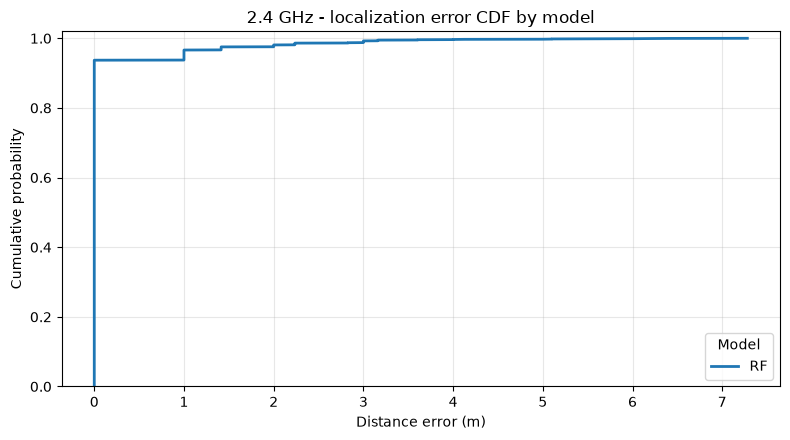

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/ml__rf__2_4ghz__random__ebl-session__s42__f857e6/cdf_by_model_5-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


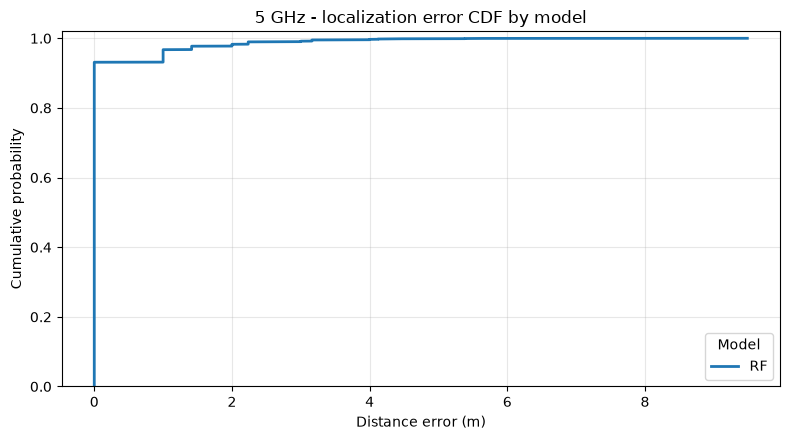

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/ml__rf__2_4ghz__random__ebl-session__s42__f857e6/cdf_by_model_fusion.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


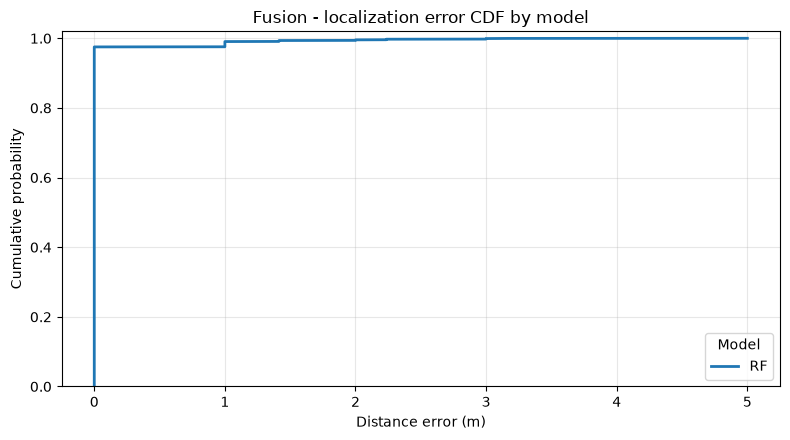

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/ml__rf__2_4ghz__random__ebl-session__s42__f857e6/cdf_rf_all-bands_random.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


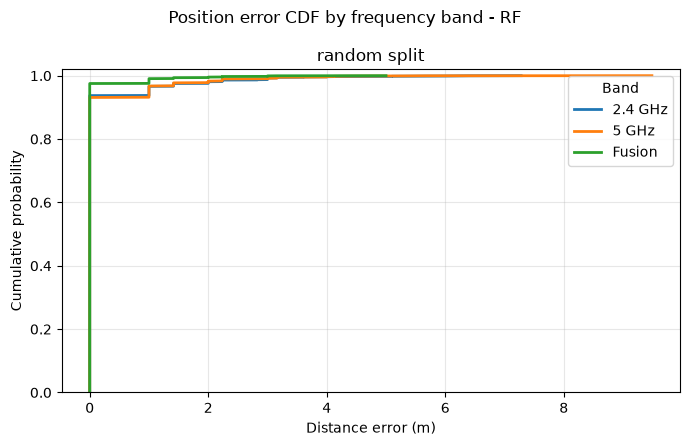

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

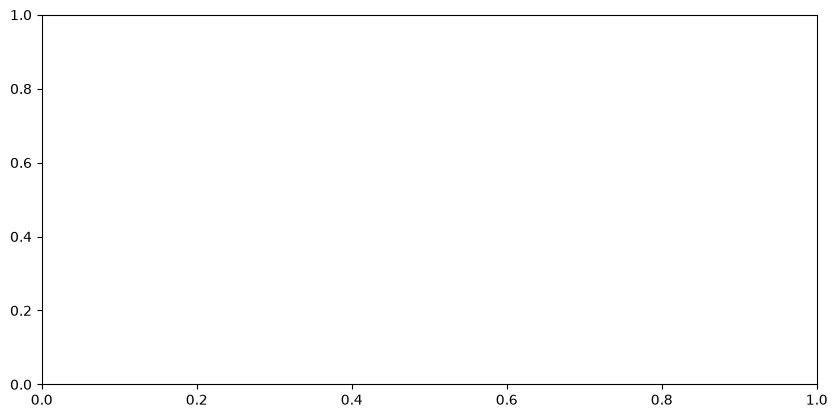

In [11]:
if SHOW_CDF_BY_BAND:
    for band in BANDS_TO_RUN:
        plot_localization_error_cdf_by_model(
            all_global_predictions,
            dataset=band,
            save_path=plots_dir / f"cdf_by_model_{_slugify(band)}.png",
        )

if SHOW_CDF_BY_MODEL:
    for model in MODELS_TO_RUN:
        model_predictions = all_global_predictions.loc[all_global_predictions["model"] == model]
        plot_band_error_cdf(
            model_predictions,
            model_label=model,
            split_modes=SPLIT_MODES,
            band_order=BANDS_TO_RUN,
            save_path=plots_dir,
        )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_global_predictions,
        models=MODELS_TO_RUN,
        bands=BANDS_TO_RUN,
        save_path=plots_dir / "boxplot_model_band_distance_error.png",
    )

#### Confusion Matrix And Floor Plan

In [ ]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_global_predictions,
    master_table,
    dataset=CONFUSION_DATASET,
    model=CONFUSION_MODEL,
)
print(f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET}")

if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=f"{CONFUSION_DATASET} / {confusion_model} localization heatmap",
        save_path=plots_dir / f"floor_plan_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.png",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=plots_dir / f"confusion_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.png",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = plots_dir / f"confusion_by_room_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )